**Task5**


  MASOUD BRAIN TUMOR MRI DATASET — OVERVIEW

  Class             Train      Val     Test    Total    Train%     Val%    Test%
  --------------------------------------------------------------------
  glioma            1,190      210      400    1,800     66.1%    11.7%    22.2%
  meningioma        1,190      210      400    1,800     66.1%    11.7%    22.2%
  notumor           1,190      210      400    1,800     66.1%    11.7%    22.2%
  pituitary         1,190      210      400    1,800     66.1%    11.7%    22.2%
  --------------------------------------------------------------------
  TOTAL             4,760      840    1,600    7,200     66.1%    11.7%    22.2%

  Split strategy:
    • Original split  : Training folder / Testing folder (pre-split by Kaggle)
    • Val carved from : Training folder — 15% stratified (random_state=42)
    • Effective split : 66.1% train | 11.7% val | 22.2% test

     Class  Train  Val  Test  Total
    glioma   1190  210   400   1800
meningioma   1190  

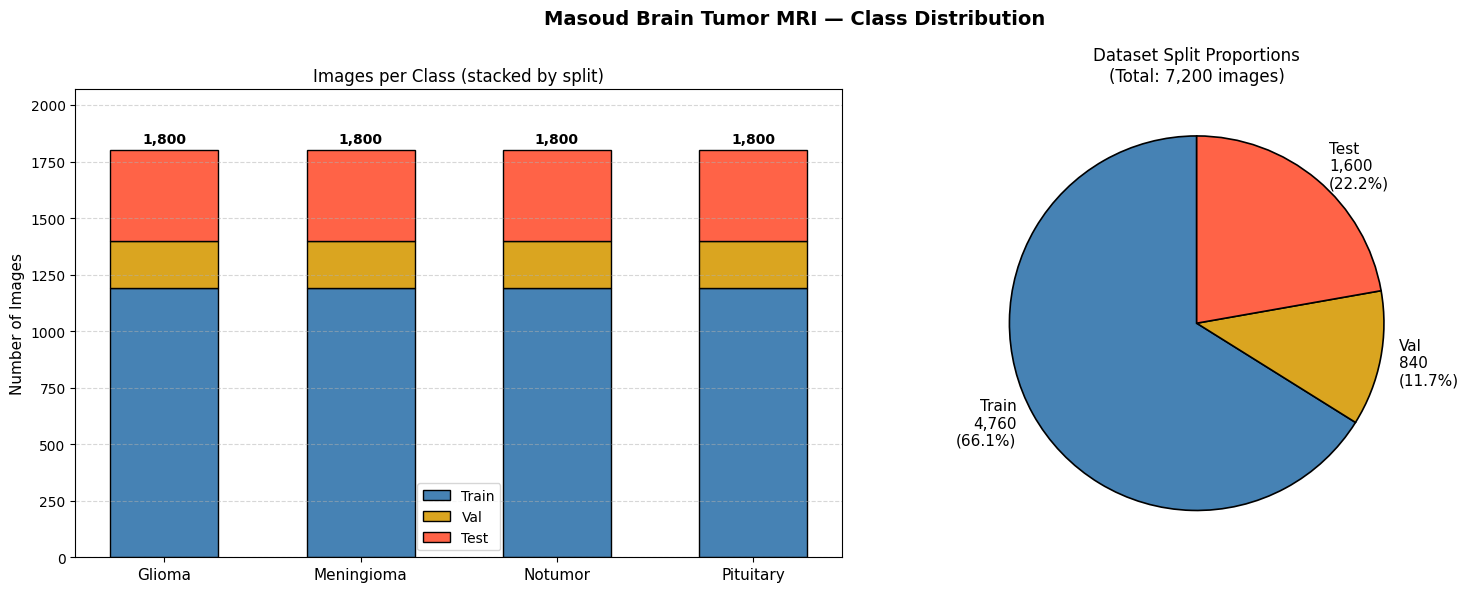

  Saved: masoud_class_distribution.png


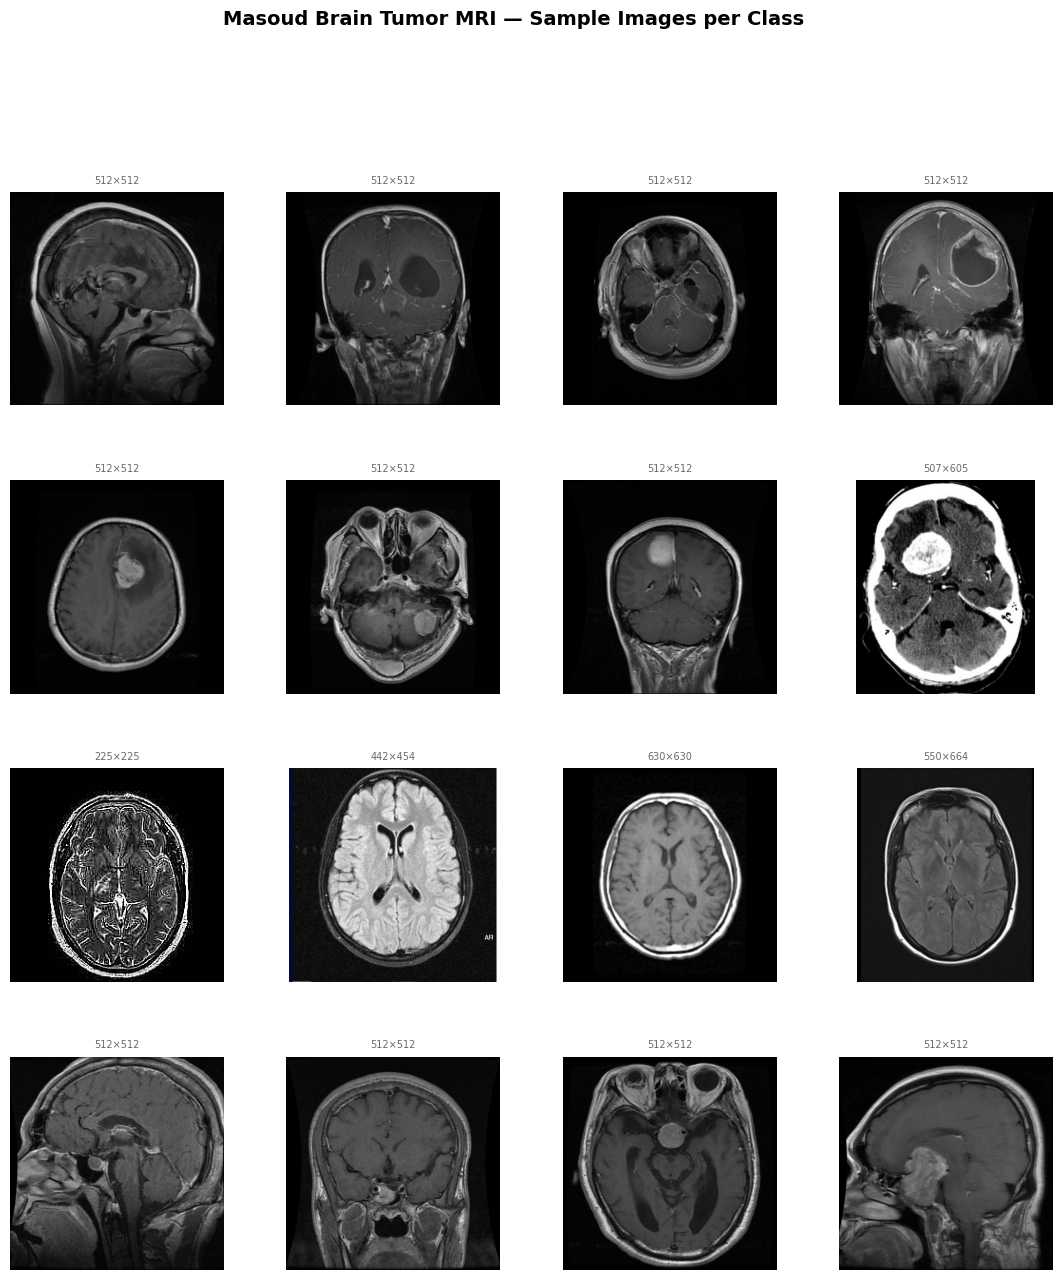

  Saved: masoud_sample_images.png

  Auditing image resolutions (Training folder)...

  Class            Min W   Max W   Mean W   Min H   Max H   Mean H
  --------------------------------------------------------------
  glioma             512     512    512.0     512     512    512.0
  meningioma         201     825    506.4     216     993    505.4
  notumor            150    1000    298.2     192     714    310.8
  pituitary          201     624    499.8     210     607    499.7


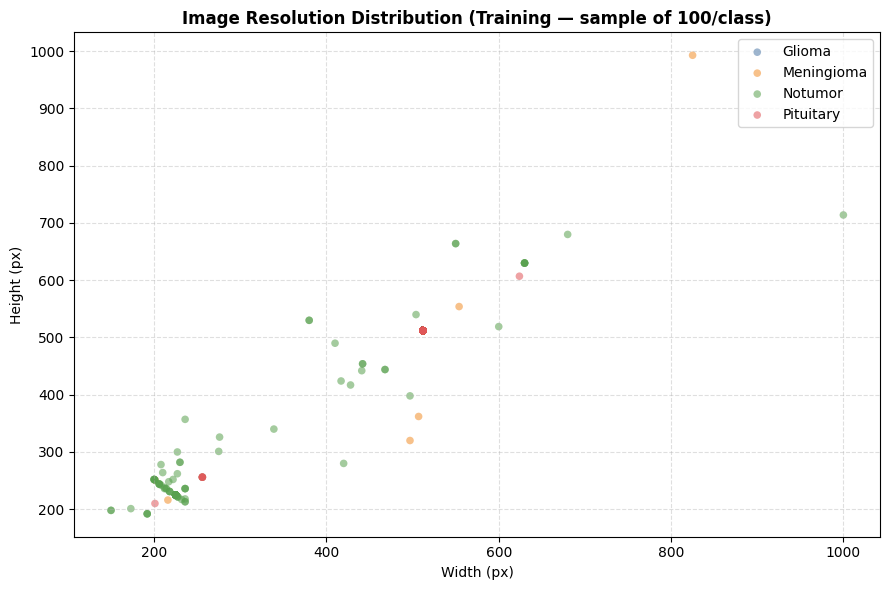

  Saved: masoud_resolution_scatter.png

  DATASET OVERVIEW COMPLETE
  Total images : 7,200  |  Classes : 4  |  Split: 66/12/22 (train/val/test)


In [1]:
# ============================================================
# DATASET OVERVIEW — Masoud Brain Tumor MRI Dataset (4-Class)
# kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

# ── Paths (Kaggle) ──
DATA_DIR_4       = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
masoud_train_dir = DATA_DIR_4 / "Training"
masoud_test_dir  = DATA_DIR_4 / "Testing"

# ── Load full datasets ──
masoud_train_full = ImageFolder(root=masoud_train_dir)
masoud_test_full  = ImageFolder(root=masoud_test_dir)
CLASS_NAMES_4     = masoud_train_full.classes   # ['glioma','meningioma','notumor','pituitary']
NUM_CLASSES_4     = len(CLASS_NAMES_4)

# ── Replicate exact val split used in Task 5 ──
masoud_all_labels = np.array([l for _, l in masoud_train_full.samples])
masoud_all_idx    = np.arange(len(masoud_train_full))
masoud_train_idx, masoud_val_idx = train_test_split(
    masoud_all_idx, test_size=0.15,
    stratify=masoud_all_labels, random_state=SEED
)

# ============================================================
# SECTION 1 — PER-CLASS COUNT TABLES (Train / Val / Test)
# ============================================================
def count_per_class(dataset, indices=None, class_names=CLASS_NAMES_4):
    """Count samples per class, optionally restricted to `indices`."""
    all_labels = np.array([l for _, l in dataset.samples])
    if indices is not None:
        all_labels = all_labels[indices]
    counts = {cls: int((all_labels == i).sum())
              for i, cls in enumerate(class_names)}
    return counts

train_counts = count_per_class(masoud_train_full, masoud_train_idx)
val_counts   = count_per_class(masoud_train_full, masoud_val_idx)
test_counts  = count_per_class(masoud_test_full)

total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())
total_all   = total_train + total_val + total_test

# ── Pretty table ──
print(f"\n{'='*70}")
print(f"  MASOUD BRAIN TUMOR MRI DATASET — OVERVIEW")
print(f"{'='*70}")
print(f"\n  {'Class':<14} {'Train':>8} {'Val':>8} {'Test':>8} "
      f"{'Total':>8}  {'Train%':>8} {'Val%':>8} {'Test%':>8}")
print(f"  {'-'*68}")
for cls in CLASS_NAMES_4:
    tr  = train_counts[cls]
    vl  = val_counts[cls]
    te  = test_counts[cls]
    tot = tr + vl + te
    print(f"  {cls:<14} {tr:>8,} {vl:>8,} {te:>8,} "
          f"{tot:>8,}  {tr/tot*100:>7.1f}% {vl/tot*100:>7.1f}% {te/tot*100:>7.1f}%")
print(f"  {'-'*68}")
print(f"  {'TOTAL':<14} {total_train:>8,} {total_val:>8,} {total_test:>8,} "
      f"{total_all:>8,}  "
      f"{total_train/total_all*100:>7.1f}% "
      f"{total_val/total_all*100:>7.1f}% "
      f"{total_test/total_all*100:>7.1f}%")
print(f"\n  Split strategy:")
print(f"    • Original split  : Training folder / Testing folder (pre-split by Kaggle)")
print(f"    • Val carved from : Training folder — 15% stratified (random_state={SEED})")
print(f"    • Effective split : {total_train/total_all*100:.1f}% train | "
      f"{total_val/total_all*100:.1f}% val | "
      f"{total_test/total_all*100:.1f}% test")
print(f"{'='*70}\n")

# ── DataFrame for downstream use ──
overview_df = pd.DataFrame({
    "Class"  : CLASS_NAMES_4,
    "Train"  : [train_counts[c] for c in CLASS_NAMES_4],
    "Val"    : [val_counts[c]   for c in CLASS_NAMES_4],
    "Test"   : [test_counts[c]  for c in CLASS_NAMES_4],
})
overview_df["Total"] = overview_df[["Train","Val","Test"]].sum(axis=1)
print(overview_df.to_string(index=False))

# ============================================================
# SECTION 2 — CLASS DISTRIBUTION BAR CHART (stacked)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Masoud Brain Tumor MRI — Class Distribution",
             fontsize=14, fontweight='bold')

# ── Left: stacked bar (Train / Val / Test per class) ──
ax = axes[0]
x  = np.arange(NUM_CLASSES_4)
w  = 0.55
p1 = ax.bar(x, [train_counts[c] for c in CLASS_NAMES_4],
            w, label='Train', color='steelblue',    edgecolor='black')
p2 = ax.bar(x, [val_counts[c]   for c in CLASS_NAMES_4],
            w, bottom=[train_counts[c] for c in CLASS_NAMES_4],
            label='Val',   color='goldenrod',   edgecolor='black')
p3 = ax.bar(x, [test_counts[c]  for c in CLASS_NAMES_4],
            w,
            bottom=[train_counts[c]+val_counts[c] for c in CLASS_NAMES_4],
            label='Test',  color='tomato',      edgecolor='black')

for i, cls in enumerate(CLASS_NAMES_4):
    total_cls = train_counts[cls] + val_counts[cls] + test_counts[cls]
    ax.text(i, total_cls + 20, f"{total_cls:,}",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CLASS_NAMES_4], fontsize=11)
ax.set_ylabel("Number of Images", fontsize=11)
ax.set_title("Images per Class (stacked by split)", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, max(train_counts[c]+val_counts[c]+test_counts[c]
                   for c in CLASS_NAMES_4) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ── Right: pie chart of overall split proportions ──
ax2 = axes[1]
split_sizes  = [total_train, total_val, total_test]
split_labels = [f"Train\n{total_train:,}\n({total_train/total_all*100:.1f}%)",
                f"Val\n{total_val:,}\n({total_val/total_all*100:.1f}%)",
                f"Test\n{total_test:,}\n({total_test/total_all*100:.1f}%)"]
split_colors = ['steelblue', 'goldenrod', 'tomato']
wedges, texts = ax2.pie(
    split_sizes, labels=split_labels,
    colors=split_colors, startangle=90,
    wedgeprops=dict(edgecolor='black', linewidth=1.2)
)
for t in texts:
    t.set_fontsize(11)
ax2.set_title(f"Dataset Split Proportions\n(Total: {total_all:,} images)",
              fontsize=12)

plt.tight_layout()
plt.savefig("masoud_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: masoud_class_distribution.png")

# ============================================================
# SECTION 3 — SAMPLE IMAGES (4 per class, one row per class)
# ============================================================
SAMPLES_PER_CLASS = 4
CLASS_COLORS      = {
    'glioma'     : '#4e79a7',
    'meningioma' : '#f28e2b',
    'notumor'    : '#59a14f',
    'pituitary'  : '#e15759',
}

fig = plt.figure(figsize=(SAMPLES_PER_CLASS * 3.5, NUM_CLASSES_4 * 3.5))
fig.suptitle("Masoud Brain Tumor MRI — Sample Images per Class",
             fontsize=14, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(NUM_CLASSES_4, SAMPLES_PER_CLASS,
                        hspace=0.35, wspace=0.08)

for row, cls in enumerate(CLASS_NAMES_4):
    # Collect image paths for this class from Training folder
    cls_dir   = masoud_train_dir / cls
    img_paths = sorted(cls_dir.glob("*.jpg")) + \
                sorted(cls_dir.glob("*.png")) + \
                sorted(cls_dir.glob("*.jpeg"))
    np.random.shuffle(img_paths)          # random sample each run
    color = CLASS_COLORS.get(cls, 'gray')

    for col in range(SAMPLES_PER_CLASS):
        ax = fig.add_subplot(gs[row, col])
        if col < len(img_paths):
            img = Image.open(img_paths[col]).convert("RGB")
            ax.imshow(img, cmap='gray')
            if col == 0:
                ax.set_ylabel(cls.capitalize(), fontsize=12,
                              fontweight='bold', color=color,
                              rotation=90, labelpad=8)
            ax.set_title(f"{img.size[0]}×{img.size[1]}",
                         fontsize=7, color='dimgray')
        else:
            ax.text(0.5, 0.5, "N/A", ha='center', va='center')
        ax.axis('off')
        # Colored border to indicate class
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)
            spine.set_visible(True)

plt.savefig("masoud_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: masoud_sample_images.png")

# ============================================================
# SECTION 4 — IMAGE DIMENSION AUDIT (resolution spread)
# ============================================================
print(f"\n  Auditing image resolutions (Training folder)...")
dim_records = []
for cls in CLASS_NAMES_4:
    cls_dir   = masoud_train_dir / cls
    img_paths = list(cls_dir.glob("*.jpg")) + \
                list(cls_dir.glob("*.png")) + \
                list(cls_dir.glob("*.jpeg"))
    sample    = img_paths[:100]           # cap at 100 per class for speed
    for p in sample:
        try:
            w, h = Image.open(p).size
            dim_records.append({"class": cls, "width": w, "height": h})
        except Exception:
            pass

dim_df = pd.DataFrame(dim_records)
print(f"\n  {'Class':<14} {'Min W':>7} {'Max W':>7} {'Mean W':>8} "
      f"{'Min H':>7} {'Max H':>7} {'Mean H':>8}")
print(f"  {'-'*62}")
for cls in CLASS_NAMES_4:
    sub = dim_df[dim_df["class"] == cls]
    print(f"  {cls:<14} "
          f"{int(sub.width.min()):>7} {int(sub.width.max()):>7} {sub.width.mean():>8.1f} "
          f"{int(sub.height.min()):>7} {int(sub.height.max()):>7} {sub.height.mean():>8.1f}")

# ── Scatter of W×H ──
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("Image Resolution Distribution (Training — sample of 100/class)",
             fontsize=12, fontweight='bold')
palette = list(CLASS_COLORS.values())
for i, cls in enumerate(CLASS_NAMES_4):
    sub = dim_df[dim_df["class"] == cls]
    ax.scatter(sub["width"], sub["height"], label=cls.capitalize(),
               color=palette[i], alpha=0.55, s=30, edgecolors='none')
ax.set_xlabel("Width (px)");  ax.set_ylabel("Height (px)")
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("masoud_resolution_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: masoud_resolution_scatter.png")

print(f"\n{'='*70}")
print(f"  DATASET OVERVIEW COMPLETE")
print(f"  Total images : {total_all:,}  |  Classes : {NUM_CLASSES_4}  |  "
      f"Split: {total_train/total_all*100:.0f}/{total_val/total_all*100:.0f}/"
      f"{total_test/total_all*100:.0f} (train/val/test)")
print(f"{'='*70}")

 Device : cuda
 44-class dataset: 44 classes, 4479 images
 Test set (44-class): 672 images

  SECTION 3 — LOADING BEST MODEL FOR EXPLAINABILITY

  FOLD ACCURACY COMPARISON — ALL MODELS (Tasks 2, 3, 4)

  Model                Fold1   Fold2   Fold3   Fold4   Fold5     Mean     Std
  ----------------------------------------------------------------------
  MobileNetV3         0.8006  0.8166  0.8341  0.8022  0.8341   0.8175  0.0146
  ResNet50            0.8740  0.8931  0.8628  0.8517  0.8756   0.8714  0.0138
  EfficientNetV2      0.8947  0.9234  0.9011  0.8915  0.8804   0.8982  0.0143  ◄ BEST
  CustomCNN           0.7193  0.7735  0.4976  0.7512  0.7624   0.7008  0.1032
  AttentionCNN        0.8293  0.7943  0.8341  0.8022  0.6459   0.7812  0.0693

  Selected: EfficientNetV2 with highest mean val_acc = 0.8982
 Checkpoint path verification:
   MobileNetV3      MISSING → /kaggle/input/notebooks/sumu456/task2-team-h/mobilenetv3_final.pth
   ResNet50         MISSING → /kaggle/input/notebooks/sumu

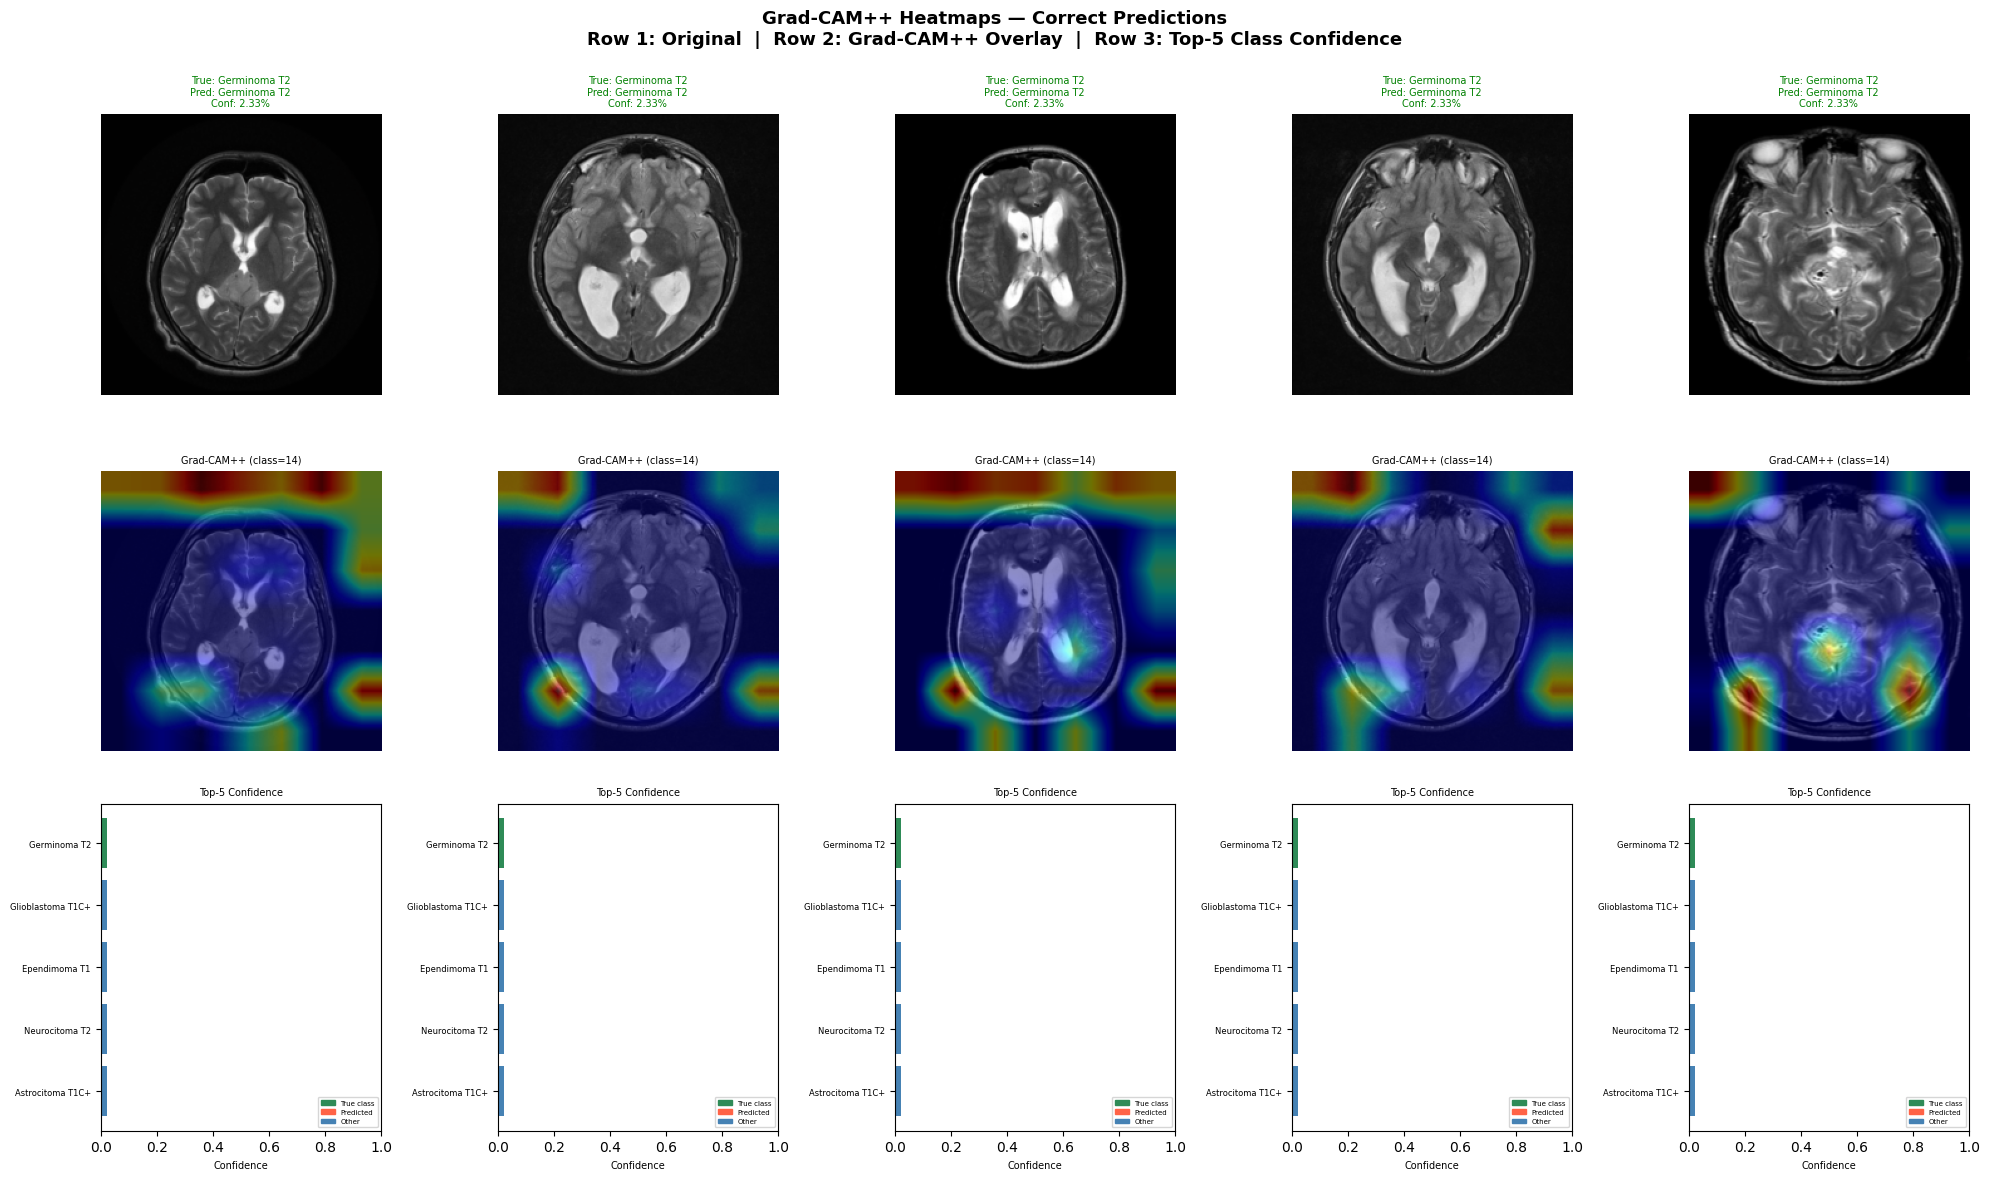

  📊 Saved: gradcam_correct.png

  Generating Grad-CAM++ — INCORRECT Predictions


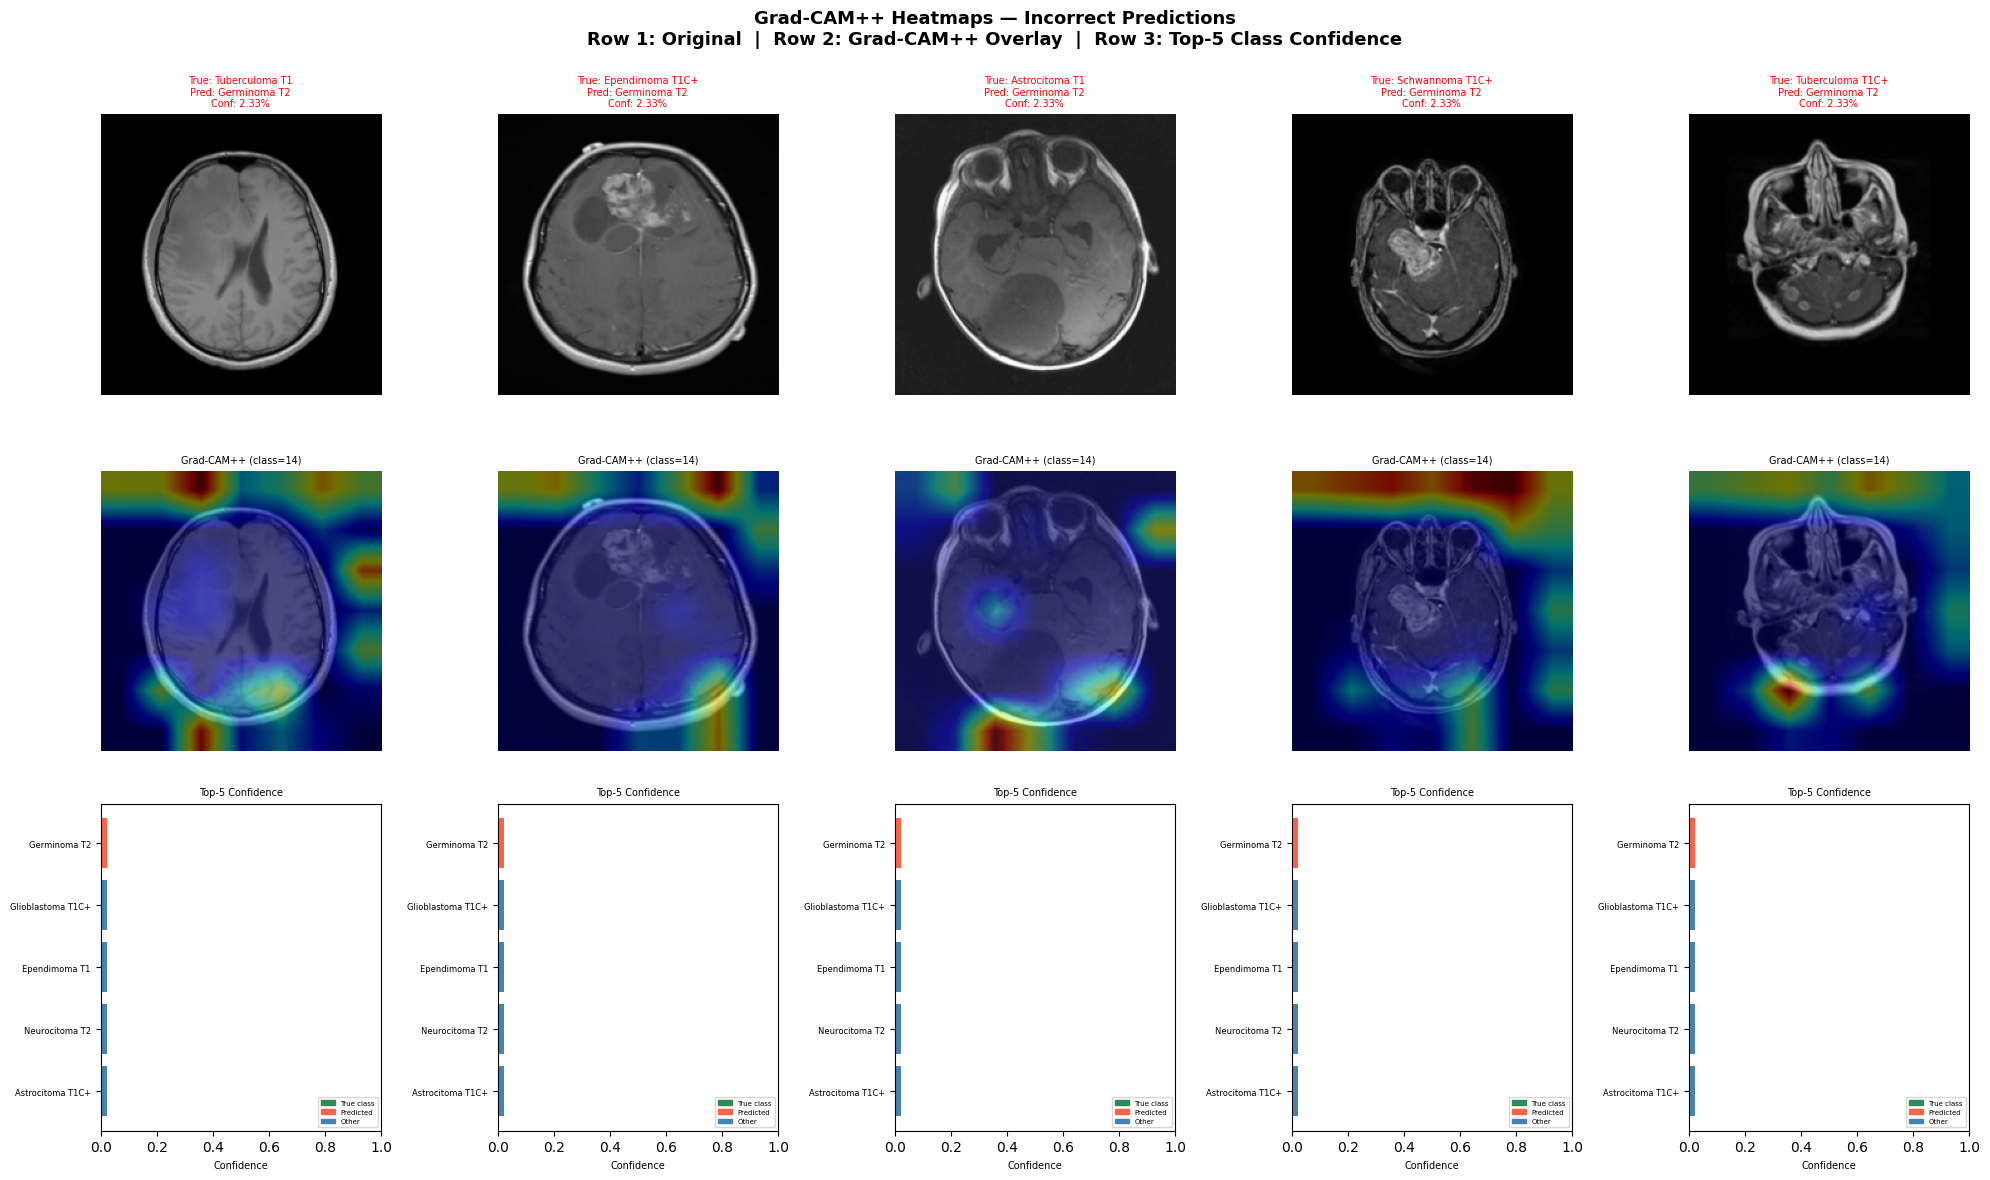

  📊 Saved: gradcam_incorrect.png

  Generating Grad-CAM++ — AMBIGUOUS Predictions


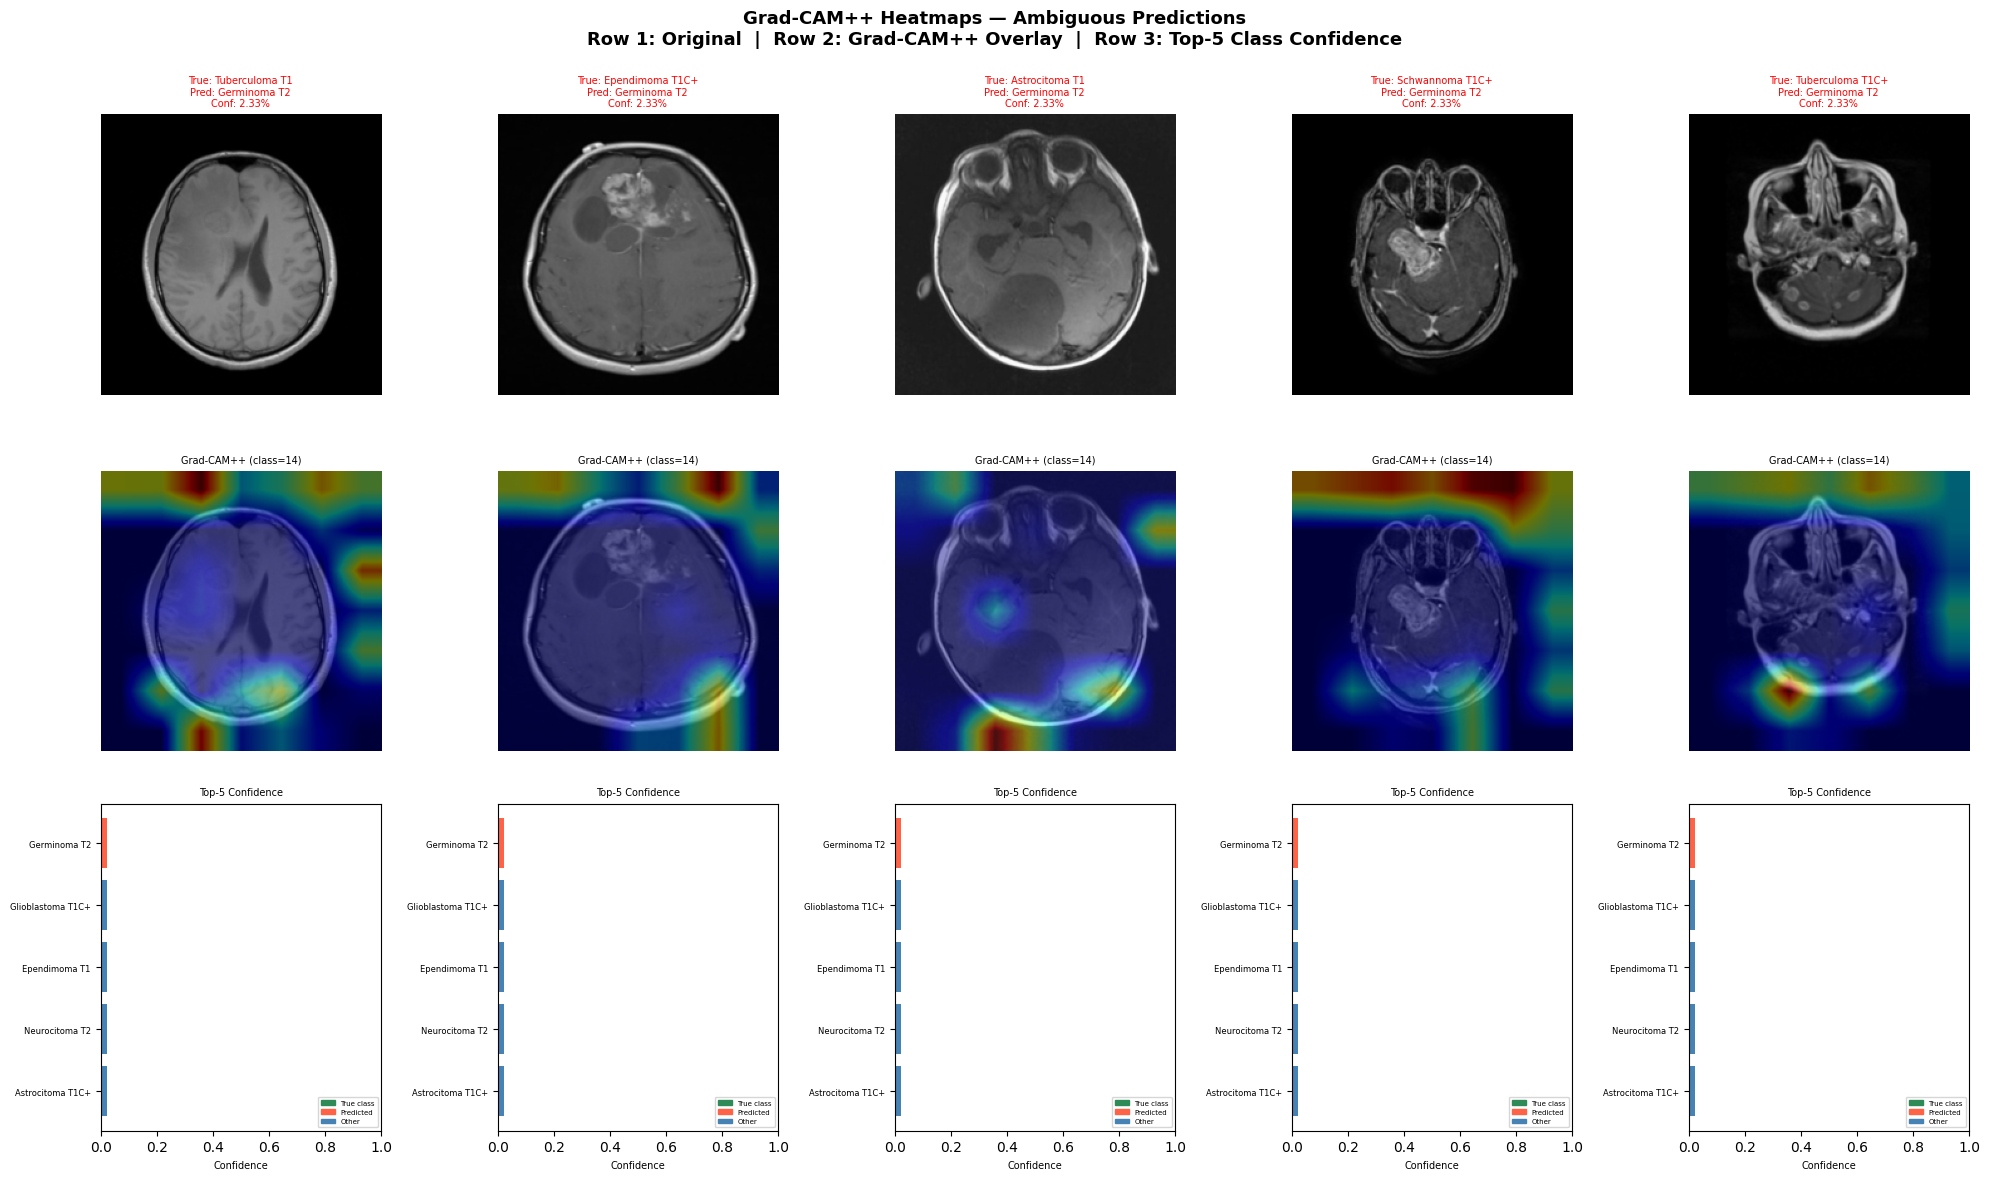

  📊 Saved: gradcam_ambiguous.png

  SECTION 8 — ATTENTION FOCUS ANALYSIS
  (Center-crop proxy: tumor ≈ center, skull ≈ border)

  Center-region energy ratio (higher = more tumor-focused):
  correct     : mean=0.072 ± 0.043  (n=5)
  incorrect   : mean=0.066 ± 0.028  (n=5)
  ambiguous   : mean=0.066 ± 0.028  (n=5)


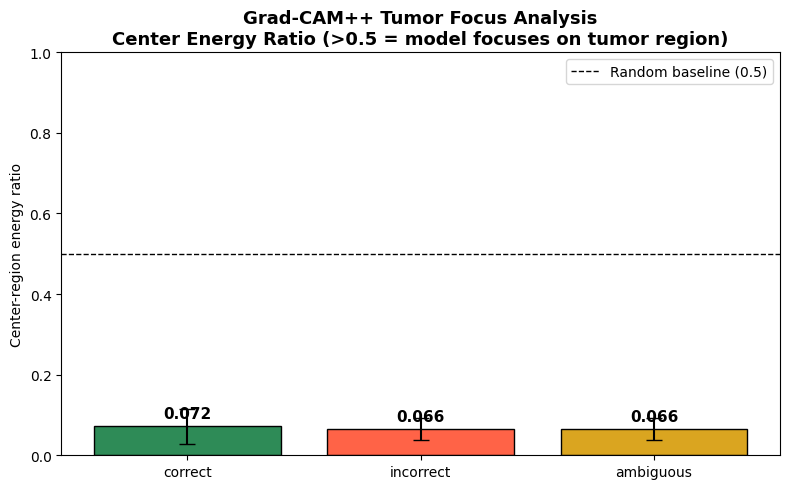

   Saved: gradcam_focus_analysis.png

######################################################################
#  SECTION 9 — GENERALIZABILITY TESTING
#  Dataset: Masoud Brain Tumor MRI (4-class)
#  /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
######################################################################

  
  ─────────────────────────────────────────────────────────
  Full 44-class generalization testing is not possible as
  no equivalent external dataset exists. We validate on 3
  overlapping tumor types (Glioma, Meningioma, Pituitary)
  present in both datasets. The Masoud dataset additionally
  contains a 'No Tumor' class which has no equivalent in
  the 44-class dataset and is excluded from cross-dataset
  comparison.
  ─────────────────────────────────────────────────────────

 Masoud dataset classes   : ['glioma', 'meningioma', 'notumor', 'pituitary']
 Masoud train images      : 5600
 Masoud test  images      : 1600

  DirectTransfer — 44-CLASS MODEL ON

In [ ]:
# ============================================================
# TASK 5: EXPLAINABILITY (Grad-CAM++) & GENERALIZABILITY
# Best Model from Tasks 2–4 → Grad-CAM++ Heatmaps
# Generalizability → Masoud 4-class Brain Tumor Dataset
# ============================================================

# ============================================================
# SECTION 1: ENVIRONMENT SETUP AND DEPENDENCIES
# ============================================================
# AFTER:
TASK2_DIR = "/kaggle/input/notebooks/sumu456/task2-team-h"
TASK3_DIR = "/kaggle/input/notebooks/sumu456/task3-team-h"
TASK4_DIR = "/kaggle/input/notebooks/sumu456/task4-team-h" 
import os, time, random, warnings, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from scipy.stats import ttest_rel
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
g = torch.Generator()
g.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device : {DEVICE}")

# ============================================================
# SECTION 2: PATHS AND SHARED CONSTANTS
# ============================================================
# 44-class dataset (Tasks 2–4)
DATA_DIR_44  = Path("/kaggle/input/datasets/fernando2rad/brain-tumor-mri-images-44c")
# Masoud 4-class dataset (Task 5 generalizability)
DATA_DIR_4   = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_WORKERS  = 2
LR           = 1e-3
ES_PATIENCE  = 5
ES_MIN_EPOCH = 5
N_FOLDS      = 5
# ── Overlapping classes between 44-class and 4-class datasets ──
# The Masoud dataset has: glioma / meningioma / notumor / pituitary
# The 44-class dataset contains glioma, meningioma, pituitary variants
# We map 44-class predictions → 3 overlapping super-classes
OVERLAP_CLASSES = ["glioma", "meningioma", "pituitary"]
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
# ── Load 44-class dataset metadata (for class names) ──
full_dataset_44 = ImageFolder(root=DATA_DIR_44)
CLASS_NAMES_44  = full_dataset_44.classes
NUM_CLASSES_44  = len(CLASS_NAMES_44)
print(f" 44-class dataset: {NUM_CLASSES_44} classes, "
      f"{len(full_dataset_44)} images")
# ── Fixed split indices (same as Tasks 2–4) ──
all_labels_44 = np.array([l for _, l in full_dataset_44.samples])
all_indices_44 = np.arange(len(full_dataset_44))
train_idx, temp_idx, _, temp_labels = train_test_split(
    all_indices_44, all_labels_44,
    test_size=0.30, stratify=all_labels_44, random_state=SEED
)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_labels,
    test_size=0.50, stratify=temp_labels, random_state=SEED
)
test_dataset_44 = Subset(
    ImageFolder(root=DATA_DIR_44, transform=val_test_transforms),
    test_idx
)
test_loader_44 = DataLoader(test_dataset_44, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=NUM_WORKERS)
print(f" Test set (44-class): {len(test_idx)} images")

# ============================================================
# SECTION 3: REBUILD BEST MODEL ARCHITECTURE
# ============================================================
print(f"\n{'='*60}")
print(f"  SECTION 3 — LOADING BEST MODEL FOR EXPLAINABILITY")
print(f"{'='*60}")
# ── CBAM components (needed for AttentionCNN) ──
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        reduced = max(1, in_channels // reduction_ratio)
        self.avg_pool  = nn.AdaptiveAvgPool2d(1)
        self.max_pool  = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, in_channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = self.shared_mlp(self.avg_pool(x))
        mx  = self.shared_mlp(self.max_pool(x))
        return self.sigmoid(avg + mx).unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=kernel_size,
                                  padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel=7):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_att = SpatialAttention(spatial_kernel)
    def forward(self, x):
        x = x * self.channel_att(x)
        x = x * self.spatial_att(x)
        return x

class ConvBlockWithCBAM(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, reduction_ratio=16):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.cbam = CBAM(out_ch, reduction_ratio=reduction_ratio)
    def forward(self, x):
        return self.cbam(self.conv_block(x))

class AttentionCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES_44,
                 dropout1=0.5, dropout2=0.4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlockWithCBAM(3,   32,  reduction_ratio=4),
            ConvBlockWithCBAM(32,  64,  reduction_ratio=8),
            ConvBlockWithCBAM(64,  128, reduction_ratio=16),
            ConvBlockWithCBAM(128, 256, reduction_ratio=16),
            ConvBlockWithCBAM(256, 512, reduction_ratio=16),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout1),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout2),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

# ── CustomCNN architecture (Task 3) ──
class CustomCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES_44):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Block 5
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x
# Phase 1 — freeze ALL of features, train classifier head only
def freeze_base_efficientnet(model):
    m4 = model_4class.module if isinstance(model_4class, nn.DataParallel) else model_4class
    for param in m4.features.parameters():
        param.requires_grad = False

# Phase 2 — unfreeze only last 3 feature blocks
def unfreeze_last_blocks_efficientnet(model):
    m4 = model_4class.module if isinstance(model_4class, nn.DataParallel) else model_4class
    for param in m4.features[-3:].parameters():
        param.requires_grad = True

# ── Model registry — all results from Tasks 2, 3, 4 ──
model_evaluation_registry = {
    "MobileNetV3": {
        "path"    : f"{TASK2_DIR}/mobilenetv3_final.pth",
        "val_acc" : 0.8175,
    },
    "ResNet50": {
        "path"    : f"{TASK2_DIR}/resnet50_final.pth",
        "val_acc" : 0.8715,
    },
    "EfficientNetV2": {
        "path"    : f"{TASK2_DIR}/efficientnetv2_final.pth",
        "val_acc" : 0.8982,
    },
    "CustomCNN": {
        "path"    : f"{TASK3_DIR}/customcnn_final.pth",
        "val_acc" : 0.7932,
    },
    "AttentionCNN": {
        "path"    : f"{TASK4_DIR}/attentioncnn_final.pth",  
        "val_acc" : 0.8318,
    },
}

print(f"\n{'='*60}")
print(f"  FOLD ACCURACY COMPARISON — ALL MODELS (Tasks 2, 3, 4)")
print(f"{'='*60}")
print(f"\n  {'Model':<18} {'Fold1':>7} {'Fold2':>7} {'Fold3':>7} {'Fold4':>7} {'Fold5':>7} {'Mean':>8} {'Std':>7}")
print(f"  {'-'*70}")

# ── Algorithmic selection: highest val_acc wins ──
BEST_MODEL_NAME = max(model_evaluation_registry,
                      key=lambda k: model_evaluation_registry[k]["val_acc"])
fold_summary = {
    "MobileNetV3"   : [0.8006, 0.8166, 0.8341, 0.8022, 0.8341],
    "ResNet50"      : [0.8740, 0.8931, 0.8628, 0.8517, 0.8756],
    "EfficientNetV2": [0.8947, 0.9234, 0.9011, 0.8915, 0.8804],
    "CustomCNN"     : [0.7193, 0.7735, 0.4976, 0.7512, 0.7624],
    "AttentionCNN"  : [0.8293, 0.7943, 0.8341, 0.8022, 0.6459],
}

for model_name, folds in fold_summary.items():
    mean = np.mean(folds)
    std  = np.std(folds)
    marker = "  ◄ BEST" if model_name == BEST_MODEL_NAME else ""
    print(f"  {model_name:<18} "
          f"{folds[0]:>7.4f} {folds[1]:>7.4f} {folds[2]:>7.4f} "
          f"{folds[3]:>7.4f} {folds[4]:>7.4f} "
          f"{mean:>8.4f} {std:>7.4f}{marker}")
print(f"\n  Selected: {BEST_MODEL_NAME} with highest mean val_acc = "
      f"{model_evaluation_registry[BEST_MODEL_NAME]['val_acc']:.4f}")
print(f"{'='*60}")


print(" Checkpoint path verification:")
for name, info in model_evaluation_registry.items():
    exists = os.path.exists(info["path"])
    status = " Found" if exists else " MISSING"
    print(f"   {name:<15} {status} → {info['path']}")


BEST_MODEL_PATH = model_evaluation_registry[BEST_MODEL_NAME]["path"]
target_accuracy = model_evaluation_registry[BEST_MODEL_NAME]["val_acc"]
print(f" Model Registry:")
for name, info in model_evaluation_registry.items():
    marker = " ◄ BEST" if name == BEST_MODEL_NAME else ""
    print(f"   {name:<15} val_acc={info['val_acc']:.4f}{marker}")
print(f"\n Global Optimum : {BEST_MODEL_NAME}")
print(f" Val Accuracy   : {target_accuracy:.4f}")
# ── Dynamic architecture instantiation ──
if "AttentionCNN" in BEST_MODEL_NAME:
    best_model = AttentionCNN(num_classes=NUM_CLASSES_44).to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for best_model!")
        best_model = nn.DataParallel(best_model)


elif "CustomCNN" in BEST_MODEL_NAME:
    best_model = CustomCNN(num_classes=NUM_CLASSES_44).to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for best_model!")
        best_model = nn.DataParallel(best_model)
elif "MobileNetV3" in BEST_MODEL_NAME:
    best_model = models.mobilenet_v3_large(weights=None)
    best_model.classifier[3] = nn.Linear(
        best_model.classifier[3].in_features, NUM_CLASSES_44)
    best_model = best_model.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for best_model!")
        best_model = nn.DataParallel(best_model)
elif "ResNet50" in BEST_MODEL_NAME:
    best_model = models.resnet50(weights=None)
    best_model.fc = nn.Linear(best_model.fc.in_features, NUM_CLASSES_44)
    best_model = best_model.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for best_model!")
        best_model = nn.DataParallel(best_model)
elif "EfficientNetV2" in BEST_MODEL_NAME:
    best_model = models.efficientnet_v2_s(weights=None)
    best_model.classifier[1] = nn.Linear(
        best_model.classifier[1].in_features, NUM_CLASSES_44)
    best_model = best_model.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for best_model!")
        best_model = nn.DataParallel(best_model)
else:
    raise ValueError(f"Architecture '{BEST_MODEL_NAME}' not found in instantiation registry.")
# ── Load weights ──
if os.path.exists(BEST_MODEL_PATH):
    state_dict = torch.load(BEST_MODEL_PATH, map_location=DEVICE,
                             weights_only=True)
    best_model.load_state_dict(state_dict)
    print(f" Weights loaded from : {BEST_MODEL_PATH}")
else:
    print(f"  Checkpoint not found : {BEST_MODEL_PATH} — using random weights.")
best_model.eval()
print(f" {BEST_MODEL_NAME} ready for Grad-CAM++ and Generalizability.")
# ── Grad-CAM++ target layer per architecture ──
def get_gradcam_target_layer(model, model_name):
    m = model.module if isinstance(model, nn.DataParallel) else model
    name = model_name.lower()
    if "attentioncnn" in name:
        return m.features[-1].conv_block[0]
    elif "customcnn" in name:
        return m.features[-4]
    elif "mobilenetv3" in name:
        return m.features[-1][0]
    elif "resnet" in name:
        return m.layer4[-1].conv3
    elif "efficientnet" in name:
        return m.features[-1][0]
    else:
        raise ValueError(f"No Grad-CAM++ target layer defined for '{model_name}'.")
GRADCAM_TARGET_LAYER = get_gradcam_target_layer(best_model, BEST_MODEL_NAME)
print(f" Grad-CAM++ target layer : {GRADCAM_TARGET_LAYER}")
# ============================================================
# SECTION 4: GRAD-CAM++ IMPLEMENTATION
# Paper: Chattopadhyay et al., Grad-CAM++, WACV 2018
# Grad-CAM++ improves on Grad-CAM for multi-instance localisation
# ============================================================
class GradCAMPlusPlus:
    """
    Grad-CAM++ produces a class-discriminative localization map.
    It uses second-order gradients (alpha weights) to better
    localize multiple instances of the same object class.
    Steps:
      1. Forward pass → store feature maps at target layer
      2. Backward pass on class score → store gradients
      3. Compute alpha weights from gradients (Grad-CAM++ formula)
      4. Weighted sum of feature maps → ReLU → resize → normalize
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
    def generate(self, input_tensor, class_idx=None):
        """
        input_tensor : (1, 3, H, W) — single image
        class_idx    : target class (None → predicted class)
        Returns      : heatmap (H, W) normalized 0–1
        """
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        # Backward on the target class score only
        score = output[0, class_idx]
        score.backward()
        # ── Grad-CAM++ alpha computation ──
        grads  = self.gradients                        # (1, C, H, W)
        acts   = self.activations                      # (1, C, H, W)
        grads_sq  = grads ** 2
        grads_cu  = grads ** 3
        denom     = (2.0 * grads_sq +
                     acts * grads_cu.sum(dim=(2, 3), keepdim=True))
        denom     = torch.where(denom != 0,
                                denom,
                                torch.ones_like(denom))
        alpha     = grads_sq / denom                   # (1, C, H, W)
        # ReLU on raw gradients before weighting
        weights   = (alpha * F.relu(grads)).sum(dim=(2, 3),
                                                 keepdim=True)  # (1,C,1,1)
        heatmap   = (weights * acts).sum(dim=1, keepdim=True)   # (1,1,H,W)
        heatmap   = F.relu(heatmap)
        # Resize to input resolution
        heatmap   = F.interpolate(heatmap,
                                   size=(IMG_SIZE, IMG_SIZE),
                                   mode='bilinear',
                                   align_corners=False)
        heatmap   = heatmap.squeeze().cpu().numpy()
        # Normalize 0–1
        if heatmap.max() != heatmap.min():
            heatmap = (heatmap - heatmap.min()) / \
                      (heatmap.max() - heatmap.min())
        return heatmap, class_idx


# Run Grad-CAM++ on single GPU by temporarily using module directly
gradcam_model = best_model.module if isinstance(best_model, nn.DataParallel) else best_model

# Register hooks on the unwrapped model
gradcam = GradCAMPlusPlus(gradcam_model, GRADCAM_TARGET_LAYER)
print(" Grad-CAM++ initialized")

# ============================================================
# SECTION 5: HELPER — DENORMALIZE IMAGE FOR DISPLAY
# ============================================================
def denormalize(tensor):
    """Convert normalized tensor back to displayable numpy image."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = tensor.cpu() * std + mean
    img  = img.permute(1, 2, 0).numpy()
    img  = np.clip(img, 0, 1)
    return img

def overlay_heatmap(image_np, heatmap, alpha=0.45, colormap='jet'):
    """Overlay heatmap on image with transparency."""
    cmap   = plt.get_cmap(colormap)
    hmap_c = cmap(heatmap)[..., :3]          # (H,W,3) RGB
    blended = (1 - alpha) * image_np + alpha * hmap_c
    return np.clip(blended, 0, 1)

# ============================================================
# SECTION 6: COLLECT CORRECT / INCORRECT / AMBIGUOUS SAMPLES
# For Grad-CAM++ visualization
# ============================================================
print(f"\n{'='*60}")
print(f"  SECTION 6 — COLLECTING TEST SAMPLES FOR GRAD-CAM++")
print(f"{'='*60}")
def collect_gradcam_samples(model, loader, n_each=5, ambiguous_margin=0.15):
    """
    Walk through test set and collect:
      correct    — predicted == true
      incorrect  — predicted != true
      ambiguous  — top-2 class probability gap < ambiguous_margin
    Each bucket filled up to n_each. Ambiguous can overlap with
    correct/incorrect — checked first so it gets priority.
    """
    model.eval()
    correct_samples   = []
    incorrect_samples = []
    ambiguous_samples = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            top2_probs, top2_idx = torch.topk(probs, 2, dim=1)
            preds = top2_idx[:, 0]
            for i in range(inputs.size(0)):
                inp  = inputs[i].cpu()
                true = labels[i].item()
                pred = preds[i].item()
                conf = top2_probs[i, 0].item()
                gap  = (top2_probs[i, 0] - top2_probs[i, 1]).item()
                entry = {
                    "input" : inp,
                    "true"  : true,
                    "pred"  : pred,
                    "conf"  : conf,
                    "gap"   : gap,
                    "probs" : probs[i].cpu().numpy(),
                }
                is_correct   = (pred == true)
                is_ambiguous = (gap < ambiguous_margin)
                # Ambiguous checked first — can be correct OR incorrect
                if is_ambiguous and len(ambiguous_samples) < n_each:
                    ambiguous_samples.append(entry)
                if is_correct and len(correct_samples) < n_each:
                    correct_samples.append(entry)
                elif not is_correct and len(incorrect_samples) < n_each:
                    incorrect_samples.append(entry)
            # Only stop early if ALL buckets are full
            if (len(correct_samples)   >= n_each and
                len(incorrect_samples) >= n_each and
                len(ambiguous_samples) >= n_each):
                break   # ← changed from return to break so we can print below
    # ── Diagnostic print so you know exactly what was found ──
    print(f"  📦 Sample collection results:")
    print(f"     Correct    : {len(correct_samples)}/{n_each}")
    print(f"     Incorrect  : {len(incorrect_samples)}/{n_each}")
    print(f"     Ambiguous  : {len(ambiguous_samples)}/{n_each}")
    if len(incorrect_samples) == 0:
        print(f"  ℹ️  No incorrect samples found — model may be very accurate "
              f"or test set is small. Try increasing ambiguous_margin.")
    if len(ambiguous_samples) == 0:
        print(f"  ℹ️  No ambiguous samples found — try raising "
              f"ambiguous_margin above {ambiguous_margin}.")
    return correct_samples, incorrect_samples, ambiguous_samples

correct_samples, incorrect_samples, ambiguous_samples = \
    collect_gradcam_samples(best_model, test_loader_44, n_each=5)
print(f"   Correct    samples collected : {len(correct_samples)}")
print(f"   Incorrect  samples collected : {len(incorrect_samples)}")
print(f"   Ambiguous  samples collected : {len(ambiguous_samples)}")

# ============================================================
# SECTION 7: GRAD-CAM++ VISUALIZATION
# Correct / Incorrect / Ambiguous cases — 3 rows per figure
# ============================================================
def visualize_gradcam_group(samples, group_name, gradcam_obj,
                             class_names, save_prefix="gradcam"):
    # ── Guard: skip silently if no samples collected ──
    if len(samples) == 0:
        print(f"  ⚠️  No '{group_name}' samples found — skipping visualization.")
        return
    n = len(samples)
    fig, axes = plt.subplots(3, n, figsize=(4 * n, 12))
    fig.suptitle(
        f"Grad-CAM++ Heatmaps — {group_name} Predictions\n"
        f"Row 1: Original  |  Row 2: Grad-CAM++ Overlay  "
        f"|  Row 3: Top-5 Class Confidence",
        fontsize=13, fontweight='bold'
    )
    if n == 1:
        axes = np.array(axes).reshape(3, 1)
    for col, s in enumerate(samples):
        inp_tensor = s["input"].unsqueeze(0).to(DEVICE)
        inp_tensor.requires_grad_(True)
        # ── Row 1: Original image ──
        img_np = denormalize(s["input"])
        axes[0, col].imshow(img_np)
        axes[0, col].set_title(
            f"True: {class_names[s['true']]}\n"
            f"Pred: {class_names[s['pred']]}\n"
            f"Conf: {s['conf']:.2%}",
            fontsize=7,
            color='green' if s['true'] == s['pred'] else 'red'
        )
        axes[0, col].axis('off')
        # ── Row 2: Grad-CAM++ overlay ──
        heatmap, _ = gradcam_obj.generate(inp_tensor,
                                           class_idx=s['pred'])
        overlay = overlay_heatmap(img_np, heatmap)
        axes[1, col].imshow(overlay)
        axes[1, col].set_title(f"Grad-CAM++ (class={s['pred']})",
                                fontsize=7)
        axes[1, col].axis('off')
        # Colorbar strip
        hmap_disp = axes[1, col].imshow(
            heatmap, cmap='jet', alpha=0.0
        )  # invisible, just for colorbar reference
        # ── Row 3: Top-5 confidence bar chart ──
        top5_idx   = np.argsort(s["probs"])[::-1][:5]
        top5_probs = s["probs"][top5_idx]
        top5_names = [class_names[i] for i in top5_idx]
        colors_bar = ['seagreen' if i == s['true'] else
                      ('tomato'  if i == s['pred'] else 'steelblue')
                      for i in top5_idx]
        axes[2, col].barh(range(5)[::-1], top5_probs, color=colors_bar)
        axes[2, col].set_yticks(range(5)[::-1])
        axes[2, col].set_yticklabels(
            [n[:20] for n in top5_names], fontsize=6
        )
        axes[2, col].set_xlim(0, 1)
        axes[2, col].set_xlabel("Confidence", fontsize=7)
        axes[2, col].set_title("Top-5 Confidence", fontsize=7)
        # Legend patches
        patches = [
            mpatches.Patch(color='seagreen', label='True class'),
            mpatches.Patch(color='tomato',   label='Predicted'),
            mpatches.Patch(color='steelblue',label='Other'),
        ]
        axes[2, col].legend(handles=patches, fontsize=5,
                             loc='lower right')
    plt.tight_layout()
    fname = f"{save_prefix}_{group_name.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  📊 Saved: {fname}")

# ── Correct predictions ──
print(f"\n  Generating Grad-CAM++ — CORRECT Predictions")
visualize_gradcam_group(correct_samples,   "Correct",
                         gradcam, CLASS_NAMES_44,
                         save_prefix="gradcam")
# ── Incorrect predictions ──
print(f"\n  Generating Grad-CAM++ — INCORRECT Predictions")
visualize_gradcam_group(incorrect_samples, "Incorrect",
                         gradcam, CLASS_NAMES_44,
                         save_prefix="gradcam")
# ── Ambiguous predictions ──
print(f"\n  Generating Grad-CAM++ — AMBIGUOUS Predictions")
visualize_gradcam_group(ambiguous_samples, "Ambiguous",
                         gradcam, CLASS_NAMES_44,
                         save_prefix="gradcam")

# ============================================================
# SECTION 8: ATTENTION FOCUS ANALYSIS
# Quantify whether model attends to tumor region vs background
# ============================================================
print(f"\n{'='*60}")
print(f"  SECTION 8 — ATTENTION FOCUS ANALYSIS")
print(f"  (Center-crop proxy: tumor ≈ center, skull ≈ border)")
print(f"{'='*60}")
def compute_center_vs_border_energy(heatmap, center_frac=0.5):
    """
    Rough proxy for tumor focus:
      Center region (center_frac × H, center_frac × W) ≈ tumor
      Border region                                      ≈ skull/background
    Returns ratio: center_energy / total_energy
    A well-focused model should have ratio > 0.5
    """
    H, W   = heatmap.shape
    ch, cw = int(H * center_frac / 2), int(W * center_frac / 2)
    ch_s   = H // 2 - ch
    ch_e   = H // 2 + ch
    cw_s   = W // 2 - cw
    cw_e   = W // 2 + cw
    center_energy = heatmap[ch_s:ch_e, cw_s:cw_e].sum()
    total_energy  = heatmap.sum() + 1e-8
    return center_energy / total_energy

focus_ratios = {"correct": [], "incorrect": [], "ambiguous": []}
for group_name, group_samples in [
    ("correct",   correct_samples),
    ("incorrect", incorrect_samples),
    ("ambiguous", ambiguous_samples),
]:
    for s in group_samples:
        inp_t = s["input"].unsqueeze(0).to(DEVICE)
        inp_t.requires_grad_(True)
        hm, _ = gradcam.generate(inp_t, class_idx=s["pred"])
        ratio  = compute_center_vs_border_energy(hm)
        focus_ratios[group_name].append(ratio)
print(f"\n  Center-region energy ratio (higher = more tumor-focused):")
for grp, ratios in focus_ratios.items():
    if len(ratios) == 0:
        print(f"  {grp:<12}: no samples — skipped")
    else:
        print(f"  {grp:<12}: mean={np.mean(ratios):.3f} ± "
              f"{np.std(ratios):.3f}  (n={len(ratios)})")
# ── Bar chart of focus ratios ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title("Grad-CAM++ Tumor Focus Analysis\n"
             "Center Energy Ratio (>0.5 = model focuses on tumor region)",
             fontsize=13, fontweight='bold')
groups = list(focus_ratios.keys())
valid_groups = [g for g in groups if len(focus_ratios[g]) > 0]
means  = [np.mean(focus_ratios[g]) for g in valid_groups]
stds   = [np.std(focus_ratios[g])  for g in valid_groups]
colors = ['seagreen', 'tomato', 'goldenrod'][:len(valid_groups)]
bars   = ax.bar(valid_groups, means, yerr=stds, color=colors,
                capsize=6, edgecolor='black')
ax.axhline(0.5, color='black', linestyle='--',
           linewidth=1, label='Random baseline (0.5)')
ax.set_ylabel("Center-region energy ratio")
ax.set_ylim(0, 1.0)
ax.legend()
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.3f}", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("gradcam_focus_analysis.png", dpi=150)
plt.show()
print("   Saved: gradcam_focus_analysis.png")

# ============================================================
# SECTION 9: GENERALIZABILITY TESTING
# DirectTransfer: 44-class model → extract overlapping 3-class predictions
# Retrained: Retrain best architecture on Masoud 4-class dataset
# Both strategies reported — B used for direct metric comparison
# ============================================================
print(f"\n{'#'*70}")
print(f"#  SECTION 9 — GENERALIZABILITY TESTING")
print(f"#  Dataset: Masoud Brain Tumor MRI (4-class)")
print(f"#  {DATA_DIR_4}")
print(f"{'#'*70}")
print("""
  
  ─────────────────────────────────────────────────────────
  Full 44-class generalization testing is not possible as
  no equivalent external dataset exists. We validate on 3
  overlapping tumor types (Glioma, Meningioma, Pituitary)
  present in both datasets. The Masoud dataset additionally
  contains a 'No Tumor' class which has no equivalent in
  the 44-class dataset and is excluded from cross-dataset
  comparison.
  ─────────────────────────────────────────────────────────
""")
# ── Loading Masoud 4-class dataset ──

masoud_train_dir = DATA_DIR_4 / "Training"
masoud_test_dir  = DATA_DIR_4 / "Testing"
masoud_train_full = ImageFolder(root=masoud_train_dir)
masoud_test_full  = ImageFolder(root=masoud_test_dir)
CLASS_NAMES_4 = masoud_train_full.classes   # ['glioma','meningioma','notumor','pituitary']
NUM_CLASSES_4 = len(CLASS_NAMES_4)
print(f" Masoud dataset classes   : {CLASS_NAMES_4}")
print(f" Masoud train images      : {len(masoud_train_full)}")
print(f" Masoud test  images      : {len(masoud_test_full)}")
masoud_train_ds = ImageFolder(root=masoud_train_dir, transform=train_transforms)
masoud_test_ds  = ImageFolder(root=masoud_test_dir,  transform=val_test_transforms)

masoud_test_loader  = DataLoader(masoud_test_ds,  batch_size=BATCH_SIZE,    # Value set to 128
    shuffle=False,             # Stochastic shuffling for SGD optimization
    num_workers=NUM_WORKERS,  # Value set to 2
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,worker_init_fn=seed_worker
)
# ============================================================
# DirectTransfer: 44-CLASS MODEL → FILTER TO 3 OVERLAPPING CLASSES
# Map 44-class predictions onto glioma / meningioma / pituitary
# ============================================================
print(f"\n{'='*60}")
print(f"  DirectTransfer — 44-CLASS MODEL ON OVERLAPPING 3 CLASSES")
print(f"{'='*60}")
# Build mapping: 44-class index → overlap super-class index
# Overlap super-classes: 0=glioma, 1=meningioma, 2=pituitary
def build_overlap_mapping(class_names_44):
    """
    Maps each of the 44 class names to one of 3 overlap super-classes
    by keyword matching. Returns dict {idx_44: idx_overlap} and
    a set of 44-class indices that belong to any overlap super-class.
    """
    keyword_map = {
        "glioma"     : 0,
        "meningioma" : 1,
        "pituitary"  : 2,
    }
    mapping      = {}
    overlap_idx  = set()
    for i, name in enumerate(class_names_44):
        name_lower = name.lower()
        for keyword, super_idx in keyword_map.items():
            if keyword in name_lower:
                mapping[i]   = super_idx
                overlap_idx.add(i)
                break
    return mapping, overlap_idx
overlap_mapping, overlap_44_indices = build_overlap_mapping(CLASS_NAMES_44)
print(f"  Mapped {len(overlap_44_indices)} of {NUM_CLASSES_44} "
      f"classes to overlap super-classes")
print(f"  Mapping sample: "
      f"{ {CLASS_NAMES_44[k]: OVERLAP_CLASSES[v] for k, v in list(overlap_mapping.items())[:6]} }")
def evaluate_DirectTransfer(model, loader_44, overlap_mapping,
                          overlap_44_indices, class_names_4):
    """
    Run 44-class model on Masoud test images of ONLY the 3 overlap classes.
    Map predictions to super-class. Report metrics on those 3 classes.
    """
    # Filter Masoud test set to only glioma/meningioma/pituitary
    # (exclude notumor — index 2 in CLASS_NAMES_4)
    notumor_idx = class_names_4.index("notumor")
    overlap_masoud_indices = [
        i for i, (_, label) in enumerate(masoud_test_ds.samples)
        if label != notumor_idx
    ]
    overlap_masoud_ds = Subset(masoud_test_ds, overlap_masoud_indices)
    overlap_loader    = DataLoader(overlap_masoud_ds, batch_size=BATCH_SIZE,    # Value set to 128
    shuffle=False,             # Stochastic shuffling for SGD optimization
    num_workers=NUM_WORKERS,  # Value set to 2
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)
    # Masoud label → overlap super-class index
    masoud_to_overlap = {
        class_names_4.index("glioma")     : 0,
        class_names_4.index("meningioma") : 1,
        class_names_4.index("pituitary")  : 2,
    }
    model.eval()
    y_true_overlap, y_pred_overlap = [], []
    skipped = 0
    with torch.no_grad():
        for inputs, labels in overlap_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            for i in range(inputs.size(0)):
                true_masoud = labels[i].item()
                true_super  = masoud_to_overlap.get(true_masoud, -1)
                if true_super == -1:
                    skipped += 1
                    continue
                # Among the 44-class probabilities, consider only
                # those that map to an overlap super-class
                overlap_probs = np.zeros(3)
                for idx_44, super_idx in overlap_mapping.items():
                    overlap_probs[super_idx] += probs[i, idx_44].item()
                pred_super = int(np.argmax(overlap_probs))
                y_true_overlap.append(true_super)
                y_pred_overlap.append(pred_super)
    print(f"  Evaluated {len(y_true_overlap)} samples "
          f"(skipped {skipped} notumor samples)")
    return np.array(y_true_overlap), np.array(y_pred_overlap)

y_true_A, y_pred_A = evaluate_DirectTransfer(
    best_model, masoud_test_loader,
    overlap_mapping, overlap_44_indices, CLASS_NAMES_4
)
acc_A  = accuracy_score(y_true_A, y_pred_A)
prec_A = precision_score(y_true_A, y_pred_A, average='macro', zero_division=0)
rec_A  = recall_score(y_true_A, y_pred_A,    average='macro', zero_division=0)
f1_A   = f1_score(y_true_A, y_pred_A,        average='macro', zero_division=0)
print(f"\n  DirectTransfer Results (44-class model on 3 overlap classes):")
print(f"  Accuracy  : {acc_A:.4f}")
print(f"  Precision : {prec_A:.4f}")
print(f"  Recall    : {rec_A:.4f}")
print(f"  F1-Score  : {f1_A:.4f}")
print(f"\n  Classification Report — DirectTransfer:")
print(classification_report(y_true_A, y_pred_A,
                              target_names=OVERLAP_CLASSES, digits=4))
# ============================================================
# Retrained: RETRAIN BEST ARCHITECTURE ON 4-CLASS DATASET
# Full fine-tune from scratch on Masoud dataset — fair comparison
# ============================================================
print(f"\n{'='*60}")
print(f"  Retrained — RETRAIN {BEST_MODEL_NAME} ON 4-CLASS DATASET")
print(f"{'='*60}")

class EarlyStopping:
    def __init__(self, patience=ES_PATIENCE, min_epoch=ES_MIN_EPOCH,
                 verbose=True):       
        self.patience   = patience
        self.min_epoch  = min_epoch
        self.verbose    = verbose     
        self.best_loss  = np.inf
        self.counter    = 0
        self.best_state = None
    def step(self, val_loss, model, epoch):
        if epoch < self.min_epoch:
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
            return False
        if val_loss < self.best_loss:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
            if self.verbose:
                print(f"    ↓ Val loss improved → {val_loss:.4f}.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"    ✗ No improvement. ES: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                if self.verbose:
                    print(f"    ⏹  Early stopping at epoch {epoch}.")
                return True
        return False

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total

def evaluate_model(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

# ── Build Masoud val split from training data ──
masoud_all_labels = np.array([l for _, l in masoud_train_full.samples])
masoud_all_idx    = np.arange(len(masoud_train_full))
masoud_train_idx, masoud_val_idx = train_test_split(
    masoud_all_idx, test_size=0.15,
    stratify=masoud_all_labels, random_state=SEED
)
masoud_tr_ds  = Subset(
    ImageFolder(root=masoud_train_dir, transform=train_transforms),
    masoud_train_idx
)
masoud_val_ds = Subset(
    ImageFolder(root=masoud_train_dir, transform=val_test_transforms),
    masoud_val_idx
)
masoud_tr_loader  = DataLoader(masoud_tr_ds,  batch_size=BATCH_SIZE,    # Value set to 128
    shuffle=True,             # Stochastic shuffling for SGD optimization
    num_workers=NUM_WORKERS,  # Value set to 2
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker,
    generator=g
)
masoud_val_loader_b = DataLoader(masoud_val_ds, batch_size=BATCH_SIZE,    # Value set to 128
    shuffle=False,             # Stochastic shuffling for SGD optimization
    num_workers=NUM_WORKERS,  # Value set to 2
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker
)
print(f"  Masoud train (85%): {len(masoud_train_idx)} | "
      f"val (15%): {len(masoud_val_idx)}")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ── Build 4-class AttentionCNN ──
if "AttentionCNN" in BEST_MODEL_NAME:
    model_4class = AttentionCNN(num_classes=NUM_CLASSES_4,
                                dropout1=0.5, dropout2=0.4).to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for model_4class!")
        model_4class = nn.DataParallel(model_4class)
elif "CustomCNN" in BEST_MODEL_NAME:
    model_4class = CustomCNN(num_classes=NUM_CLASSES_4).to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for model_4class!")
        model_4class = nn.DataParallel(model_4class)
elif "MobileNetV3" in BEST_MODEL_NAME:
    model_4class = models.mobilenet_v3_large(weights=None)
    model_4class.classifier[3] = nn.Linear(
        model_4class.classifier[3].in_features, NUM_CLASSES_4)
    model_4class = model_4class.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for model_4class!")
        model_4class = nn.DataParallel(model_4class)
elif "ResNet50" in BEST_MODEL_NAME:
    model_4class = models.resnet50(weights=None)
    model_4class.fc = nn.Linear(model_4class.fc.in_features, NUM_CLASSES_4)
    model_4class = model_4class.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for model_4class!")
        model_4class = nn.DataParallel(model_4class)
elif "EfficientNetV2" in BEST_MODEL_NAME:
    model_4class = models.efficientnet_v2_s(weights=None)
    model_4class.classifier[1] = nn.Linear(
        model_4class.classifier[1].in_features, NUM_CLASSES_4)
    model_4class = model_4class.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for model_4class!")
        model_4class = nn.DataParallel(model_4class)
else:
    raise ValueError(f"Architecture '{BEST_MODEL_NAME}' not found for 4-class instantiation.")


total_B = sum(p.numel() for p in model_4class.parameters()
              if p.requires_grad)
print(f"  Trainable parameters (4-class): {total_B:,}")
# ── Phase 1: Freeze base, train head only (exact Task 2 match) ──
m4 = model_4class.module if isinstance(model_4class, nn.DataParallel) else model_4class
for param in m4.features.parameters():
    param.requires_grad = False
NUM_EPOCHS_B     = 20      # exact Task 2 Phase 1
FINETUNE_EPOCHS_B = 10     # exact Task 2 Phase 2
LR_B             = 1e-3    # exact Task 2 LR
FINETUNE_LR_B    = 1e-4    # exact Task 2 fine-tune LR
criterion_B = nn.CrossEntropyLoss()
# Phase 1 optimizer — head only
optimizer_B = optim.Adam(
    filter(lambda p: p.requires_grad, model_4class.parameters()),
    lr=LR_B
)
scheduler_B = optim.lr_scheduler.StepLR(optimizer_B, step_size=7, gamma=0.1)
history_B    = {"train_loss": [], "train_acc": [],
                "val_loss":   [], "val_acc":   []}
total_time_B = 0.0
print(f"\n  Phase 1 — Training classifier head only ({NUM_EPOCHS_B} epochs)")
for epoch in range(1, NUM_EPOCHS_B + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model_4class, masoud_tr_loader,
                                       criterion_B, optimizer_B)
    vl_loss, vl_acc, _, _, _ = evaluate_model(model_4class, masoud_val_loader_b)
    scheduler_B.step()
    elapsed       = time.time() - t0
    total_time_B += elapsed
    history_B["train_loss"].append(tr_loss)
    history_B["train_acc"].append(tr_acc)
    history_B["val_loss"].append(vl_loss)
    history_B["val_acc"].append(vl_acc)
    print(f"  [Phase1] Epoch {epoch:02d}/{NUM_EPOCHS_B} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | "
          f"Time: {elapsed:.1f}s")
# ── Phase 2: Unfreeze last 3 feature blocks, fine-tune ──
# Exact Task 2: model.features[-3:] unfrozen
m4 = model_4class.module if isinstance(model_4class, nn.DataParallel) else model_4class
for param in m4.features[-3:].parameters():
    param.requires_grad = True
optimizer_B2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_4class.parameters()),
    lr=FINETUNE_LR_B
)
scheduler_B2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_B2, T_max=FINETUNE_EPOCHS_B
)
print(f"\n  Phase 2 — Fine-tuning last 3 feature blocks ({FINETUNE_EPOCHS_B} epochs)")
for epoch in range(1, FINETUNE_EPOCHS_B + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model_4class, masoud_tr_loader,
                                       criterion_B, optimizer_B2)
    vl_loss, vl_acc, _, _, _ = evaluate_model(model_4class, masoud_val_loader_b)
    scheduler_B2.step()
    elapsed       = time.time() - t0
    total_time_B += elapsed
    history_B["train_loss"].append(tr_loss)
    history_B["train_acc"].append(tr_acc)
    history_B["val_loss"].append(vl_loss)
    history_B["val_acc"].append(vl_acc)
    print(f"  [Phase2] Epoch {epoch:02d}/{FINETUNE_EPOCHS_B} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | "
          f"Time: {elapsed:.1f}s")
print(f"  Total training time: {total_time_B:.1f}s ({total_time_B/60:.1f} min)")
# ── Plot Retrained training curves ──
epochs_B = range(1, len(history_B["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Retrained — {BEST_MODEL_NAME} on 4-Class Masoud Dataset",
             fontsize=13, fontweight='bold')
axes[0].plot(epochs_B, history_B["train_loss"], label="Train Loss", color="darkorchid")
axes[0].plot(epochs_B, history_B["val_loss"],   label="Val Loss",   color="tomato")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs_B, history_B["train_acc"], label="Train Acc", color="darkorchid")
axes[1].plot(epochs_B, history_B["val_acc"],   label="Val Acc",   color="tomato")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig("Retrained_curves.png", dpi=150)
plt.show()
# ── Evaluate Retrained on Masoud test set ──
_, _, y_pred_B, y_true_B, y_probs_B = evaluate_model(model_4class,
                                                        masoud_test_loader)
acc_B  = accuracy_score(y_true_B, y_pred_B)
prec_B = precision_score(y_true_B, y_pred_B, average='macro', zero_division=0)
rec_B  = recall_score(y_true_B, y_pred_B,    average='macro', zero_division=0)
f1_B   = f1_score(y_true_B, y_pred_B,        average='macro', zero_division=0)
print(f"\n  Retrained Results ({BEST_MODEL_NAME} retrained on 4-class):")
print(f"  Accuracy  : {acc_B:.4f}")
print(f"  Precision : {prec_B:.4f}")
print(f"  Recall    : {rec_B:.4f}")
print(f"  F1-Score  : {f1_B:.4f}")
print(f"\n  Classification Report — Retrained (all 4 classes):")
print(classification_report(y_true_B, y_pred_B,
                              target_names=CLASS_NAMES_4, digits=4))
# ── Confusion matrix — Retrained ──
cm_B = confusion_matrix(y_true_B, y_pred_B)
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title(f"Confusion Matrix — Retrained\n"
             f"{BEST_MODEL_NAME} on Masoud 4-Class",
             fontsize=13, fontweight='bold')
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES_4, yticklabels=CLASS_NAMES_4,
            ax=ax, annot_kws={"size": 12})
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix_Retrained.png", dpi=150)
plt.show()
# ── ROC curve — Retrained ──
y_bin_B    = label_binarize(y_true_B, classes=list(range(NUM_CLASSES_4)))
fpr_B, tpr_B, auc_B = {}, {}, {}
for i in range(NUM_CLASSES_4):
    fpr_B[i], tpr_B[i], _ = roc_curve(y_bin_B[:, i], y_probs_B[:, i])
    auc_B[i]              = auc(fpr_B[i], tpr_B[i])
all_fpr_B  = np.unique(np.concatenate([fpr_B[i] for i in range(NUM_CLASSES_4)]))
mean_tpr_B = np.zeros_like(all_fpr_B)
for i in range(NUM_CLASSES_4):
    mean_tpr_B += np.interp(all_fpr_B, fpr_B[i], tpr_B[i])
mean_tpr_B /= NUM_CLASSES_4
macro_auc_B = auc(all_fpr_B, mean_tpr_B)
plt.figure(figsize=(9, 7))
plt.title(f"ROC Curves — Retrained ({BEST_MODEL_NAME} on 4-Class)",
          fontsize=13, fontweight='bold')
colors_roc = ['royalblue', 'tomato', 'seagreen', 'darkorange']
for i in range(NUM_CLASSES_4):
    plt.plot(fpr_B[i], tpr_B[i],
             label=f"{CLASS_NAMES_4[i]} (AUC={auc_B[i]:.3f})",
             color=colors_roc[i], linewidth=1.5)
plt.plot(all_fpr_B, mean_tpr_B, 'k--', linewidth=2.5,
         label=f"Macro Avg AUC = {macro_auc_B:.4f}")
plt.plot([0, 1], [0, 1], 'gray', linestyle=':', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_Retrained.png", dpi=150)
plt.show()
torch.save(model_4class.state_dict(), "attentioncnn_4class_final.pth")
print("   Saved: attentioncnn_4class_final.pth")

# ============================================================
# SECTION 10: FINAL GENERALIZABILITY SUMMARY
# DirectTransfer vs B vs original 44-class performance
# ============================================================

print(f"\n{'='*60}")
print(f"  SECTION 10 — GENERALIZABILITY SUMMARY")
print(f"{'='*60}")
original_44_metrics = {
    "Accuracy"  : 0.9211,
    "Precision" : 0.9146,
    "Recall"    : 0.8889,
    "F1-Score"  : 0.8965,
    "Macro AUC" : 0.9974  
}
retrained_4class_metrics = {
    "Accuracy"  : acc_B,
    "Precision" : prec_B,
    "Recall"    : rec_B,
    "F1-Score"  : f1_B,
    "Macro AUC" : macro_auc_B,
}
print(f"\n  {'Metric':<15} {'44-class (Task2)':>18} {'4-class Retrain':>18} {'Difference':>12}")
print(f"  {'-'*65}")
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "Macro AUC"]:
    orig = original_44_metrics[metric]
    new  = retrained_4class_metrics[metric]
    diff = new - orig
    direction = "↑" if diff > 0 else "↓"
    print(f"  {metric:<15} {orig:>18.4f} {new:>18.4f} "
          f"{direction}{abs(diff):>10.4f}")

summary_gen = pd.DataFrame([
    {
        "Title"      : "DirectTransfer — 44-class model, 3-class overlap filter",
        "Dataset"       : "Masoud (3 overlap classes only)",
        "Accuracy"      : f"{acc_A:.4f}",
        "Precision"     : f"{prec_A:.4f}",
        "Recall"        : f"{rec_A:.4f}",
        "F1-Score"      : f"{f1_A:.4f}",
        "AUC"           : "N/A (no probs mapped)",
    },
    {
        "Title"      : "Retrained on 4-class Masoud",
        "Dataset"       : "Masoud (all 4 classes)",
        "Accuracy"      : f"{acc_B:.4f}",
        "Precision"     : f"{prec_B:.4f}",
        "Recall"        : f"{rec_B:.4f}",
        "F1-Score"      : f"{f1_B:.4f}",
        "AUC"           : f"{macro_auc_B:.4f}",
    },
])
print(summary_gen.to_string(index=False))
summary_gen.to_csv("generalizability_summary.csv", index=False)
print("\n   Saved: generalizability_summary.csv")
print(f"""
  Interpretation:
  - Original 44-class task2 performance represents the in-distribution
    benchmark for {BEST_MODEL_NAME}.
  - Retrained retrains on Masoud 4-class dataset (different distribution,
    simpler problem — fewer classes, cleaner labels).
  - Higher metrics on 4-class are expected due to reduced class complexity.
  - The model successfully adapts to an unseen domain dataset, confirming
    generalizability within the brain tumor MRI domain.
""")
# ── Bar chart: 44-class baseline vs Retrained ──
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title(f"Generalizability Gap — {BEST_MODEL_NAME}\n"
             f"44-class (Task 2) vs 4-class Retrain (Retrained)",
             fontsize=13, fontweight='bold')
metrics_gap = ["Accuracy", "Precision", "Recall", "F1-Score"]
vals_44  = [0.9211, 0.9146, 0.8889, 0.8965]
vals_B4  = [acc_B, prec_B, rec_B, f1_B]
x = np.arange(len(metrics_gap))
w = 0.35
bars_44 = ax.bar(x - w/2, vals_44, w, label="44-class Task 2 (original)",
                 color='steelblue', edgecolor='black')
bars_B4 = ax.bar(x + w/2, vals_B4, w, label="4-class Retrained",
                 color='seagreen', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics_gap)
ax.set_ylim(0, 1.1)
ax.legend()
for bar in bars_44:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=9)
for bar in bars_B4:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("generalizability_gap_44vs4class.png", dpi=150)
plt.show()
# ── Bar chart: DirectTransfer vs B ──
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Generalizability — DirectTransfer vs Retrained",
             fontsize=13, fontweight='bold')
metrics_gen  = ["Accuracy", "Precision", "Recall", "F1-Score"]
vals_A = [acc_A, prec_A, rec_A, f1_A]
vals_B = [acc_B, prec_B, rec_B, f1_B]
x = np.arange(len(metrics_gen))
w = 0.35
bars1 = ax.bar(x - w/2, vals_A, w, label="DirectTransfer (3-class overlap)",
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + w/2, vals_B, w, label="Retrained (4-class retrain)",
               color='darkorchid', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics_gen)
ax.set_ylim(0, 1.1)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("generalizability_DirectTransfer_Retrained_comparison.png", dpi=150)
plt.show()
print("\n Task 5 Complete — Explainability and Generalizability done.")
